In [ ]:
# All imports needed for the training
import cv2
import glob
import keras
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.layers import Input,Dense,Conv2D,MaxPooling2D,BatchNormalization,Flatten,Dropout

In [ ]:
# Finding training and testing data
TRAIN_PATH = './fingers/train/*'
TEST_PATH = './fingers/test/*'
FILE_NAME = 'realtime_fingers_detection.keras'

# Where to save the model
MODEL_PATH = 'realtime_fingers_model/'
KERNEL = (3,3)
CLASSES = 6

# Image modifications
IMAGE_SIZE = 128
BATCH_SIZE = 32

# Amount of repititions 
EPOCHS = 50

In [ ]:
def load_dataset(path):
    """Function to load dataset into a list. """
    dataset = [(int(img_path[-6]), load_image(img_path)) for img_path in glob.glob(path)]
    return dataset

def load_image(path):
    """Formatting loaded in images.  """
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE).astype(np.uint8)
    img = np.reshape(img, (IMAGE_SIZE, IMAGE_SIZE))
    return img
def show_images(dataset, grid_size=5):
    """Showing the images that are imported"""
    _, axes = plt.subplots(grid_size, grid_size, figsize=(12, 12))
    axes = [y for x in axes for y in x]
    for (i, (label, img)) in enumerate(random.sample(dataset, grid_size**2)):
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(label)
        axes[i].axis('off')

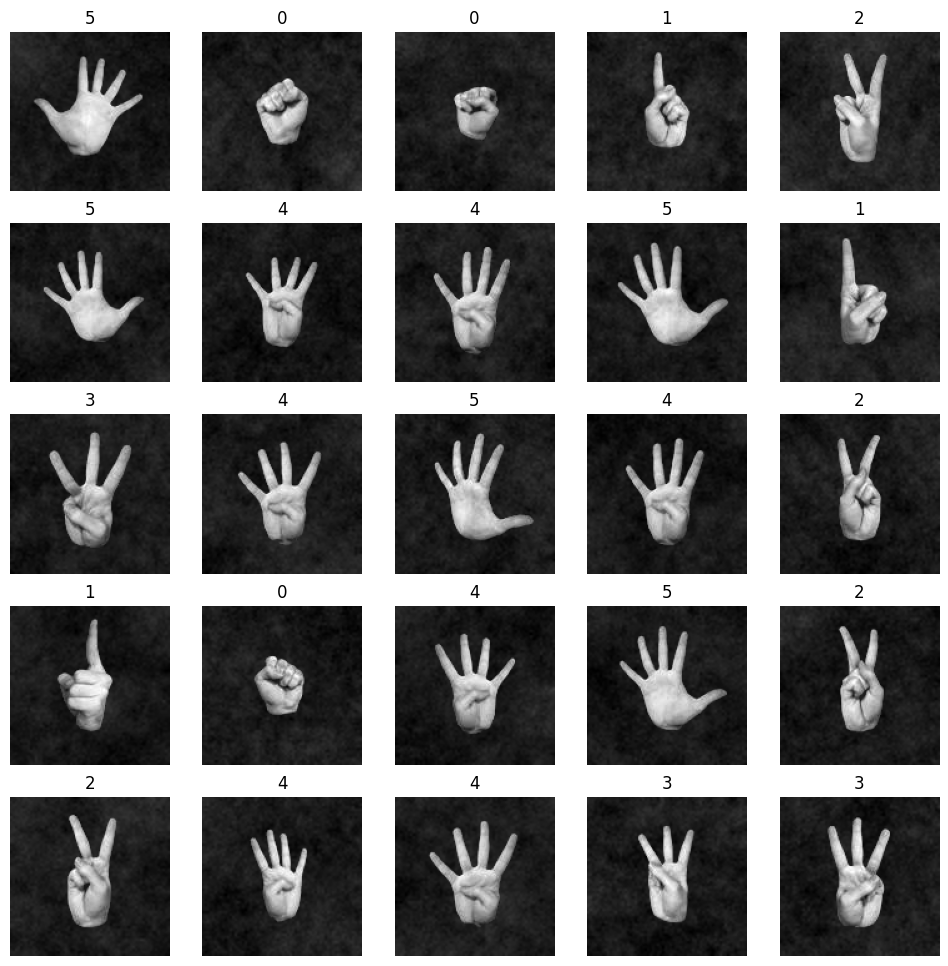

In [ ]:
# Loading dataset for training 
training_set = load_dataset(TRAIN_PATH)
testing_set = load_dataset(TEST_PATH)
show_images(training_set)

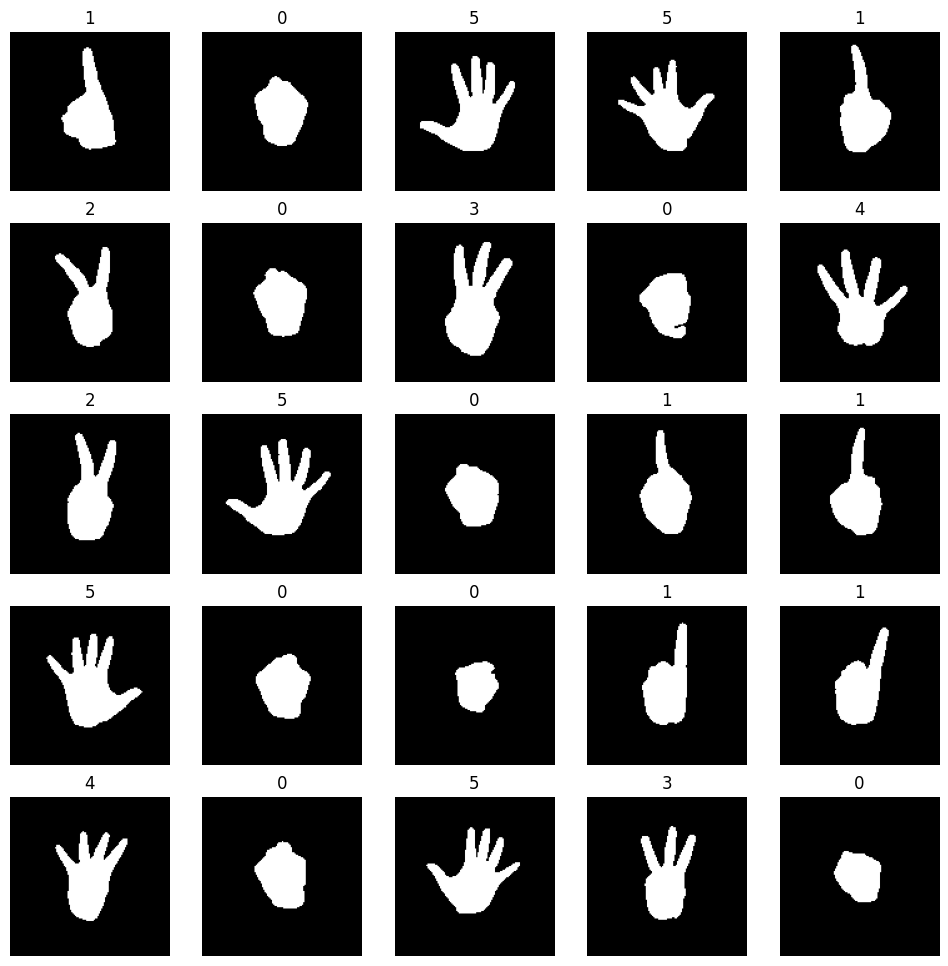

In [ ]:
def process_image(img, thresh_low=80, thresh_high=255):
    """
    Process of formatting images by applying the a mask to 
    all dataset since the actual ai will be trained on not real
    hand images, but shadows of them. 
    """
    img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
    img = cv2.GaussianBlur(img, (5, 5), 0)
    _, img = cv2.threshold(img, thresh_low, thresh_high, cv2.THRESH_BINARY)
    im_floodfill = img.copy()
    h, w = img.shape[:2]
    mask = np.zeros((h+2, w+2), np.uint8)
    cv2.floodFill(im_floodfill, mask, (0,0), 255)
    im_floodfill_inv = cv2.bitwise_not(im_floodfill)
    img = img | im_floodfill_inv    
    img = img/255
    img = np.reshape(img, (IMAGE_SIZE, IMAGE_SIZE, 1))
    return img

def process_dataset(dataset):
    """Finalizing the dataset being used for training. """
    dataset = [(label, process_image(img)) for (label, img) in dataset]
    return dataset

training_set = process_dataset(training_set)
testing_set = process_dataset(testing_set)
show_images(training_set)

In [6]:
X_train = np.array([img for (_, img) in training_set])
Y_train = keras.utils.to_categorical([label for (label, _) in training_set], num_classes=CLASSES)
X_test = np.array([img for (_, img) in testing_set])
Y_test = keras.utils.to_categorical([label for (label, _) in testing_set], num_classes=CLASSES)

print(X_train.shape)
print(Y_train.shape)

(18000, 128, 128, 1)
(18000, 6)


In [ ]:
# Adding aditional effects to hand images to diversify the dataset
img_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=45,
    zoom_range=0.2,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range = 0.1,
    horizontal_flip=False,
    fill_mode="nearest"
)

In [ ]:
def create_model():
    """
    Vectorizing the images transforming them from a 2D matrix of numbers
    into a 1D array.
    """
    input_shape=[IMAGE_SIZE, IMAGE_SIZE, 1]
        
    model = keras.models.Sequential([
            Input(input_shape),
            Conv2D(64, KERNEL, strides=(1, 1), activation='relu'),
            MaxPooling2D((2, 2)),
            BatchNormalization(),
            Conv2D(128, KERNEL, strides=(1, 1), activation='relu'),
            MaxPooling2D((2, 2)),
            BatchNormalization(),
            Conv2D(256, KERNEL, strides=(1, 1), activation='relu'),
            MaxPooling2D((2, 2)),
            BatchNormalization(),
            Conv2D(64, KERNEL, strides=(1, 1), activation='relu'),
            MaxPooling2D((2, 2)),
            BatchNormalization(),
            Dropout(0.2),
            Flatten(),
            Dense(CLASSES, activation="softmax"),
        ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [10]:
model = create_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 63, 63, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 30, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 64)     │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │        13,830 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,062 (2.03 MB)

 Trainable params: 532,038 (2.03 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [ ]:
# Save only the best weight after any significant epoch improvement
checkpoint = ModelCheckpoint(FILE_NAME, monitor='loss', verbose=1, save_best_only=True, mode='min')
reduce_lr = ReduceLROnPlateau(monitor='loss', verbose=1, factor=0.5, patience=1, min_lr=0.0001, mode='min')
earlyStopping = EarlyStopping(monitor='val_loss', verbose=1, min_delta=0, restore_best_weights = True, patience=3, mode='min')
callbacks_list = [checkpoint, earlyStopping, reduce_lr]

# Saving model progress to view improvement of time later
history = model.fit(
      x = img_generator.flow(X_train, Y_train, batch_size=BATCH_SIZE),
      steps_per_epoch= X_train.shape[0] // BATCH_SIZE,
      validation_data= img_generator.flow(X_test, Y_test, batch_size=BATCH_SIZE),
      validation_steps= X_test.shape[0] // BATCH_SIZE,
      epochs= EPOCHS,
      callbacks= callbacks_list
)

Epoch 1/50
142/562 ━━━━━━━━━━━━━━━━━━━━ 1:52 268ms/step - accuracy: 0.5141 - loss: 1.2754

KeyboardInterrupt: 

In [19]:
import tensorflow as tf

# This loads everything: architecture, weights, and optimizer state
# Note: This is NOT model.load_weights()
model = tf.keras.models.load_model('./realtime_fingers_detection.keras')

In [ ]:
# Evluating accuracy of model
loss, acc = model.evaluate(X_test, Y_test)

113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - accuracy: 0.9997 - loss: 0.0068


In [21]:
plt.figure(figsize=(16, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Loss and Accuracy')
plt.ylabel('Value')
plt.xlabel('Epoch')
plt.legend(['Train Loss', 'Validation Loss', "Accuracy", "Validation Accuracy"], loc='upper left')
plt.savefig('training.png')
plt.show()

NameError: name 'history' is not defined

<Figure size 1600x600 with 0 Axes>